# Part I - Ford GoBike System Data Exploration
## by (Gundra Yaswanth Kumar Reddy)


## Introduction

The Ford GoBike dataset contains information about individual bike-sharing trips made in the San Francisco Bay Area during February 2019. The dataset includes details such as trip duration, start and end stations, start and end times, user type, gender, birth year, and bike-sharing status. The goal of this exploratory analysis is to understand user behavior, identify riding patterns, and discover relationships between trip duration and other features.

The analysis aims to answer the following questions:

- How are trip durations distributed?
- Which user type makes the most trips?
- Does rider age influence trip duration?
- How are trip duration and user characteristics related?

In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
df = pd.read_csv('201902-fordgobike-tripdata.csv')

In [4]:
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,2019-02-28 18:53:21.7890,2019-03-01 06:42:03.0560,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,2019-02-28 23:54:18.5490,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


## Preliminary Wrangling

In [5]:
df.shape

(183412, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183412 entries, 0 to 183411
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183412 non-null  int64  
 1   start_time               183412 non-null  object 
 2   end_time                 183412 non-null  object 
 3   start_station_id         183215 non-null  float64
 4   start_station_name       183215 non-null  object 
 5   start_station_latitude   183412 non-null  float64
 6   start_station_longitude  183412 non-null  float64
 7   end_station_id           183215 non-null  float64
 8   end_station_name         183215 non-null  object 
 9   end_station_latitude     183412 non-null  float64
 10  end_station_longitude    183412 non-null  float64
 11  bike_id                  183412 non-null  int64  
 12  user_type                183412 non-null  object 
 13  member_birth_year        175147 non-null  float64
 14  memb

In [7]:
df.describe()

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,183412.000000,183215.000000,183412.000000,183412.000000,183215.000000,183412.000000,183412.000000,183412.000000,175147.000000
mean,726.078435,138.590427,37.771223,-122.352664,136.249123,37.771427,-122.352250,4472.906375,1984.806437
std,1794.389780,111.778864,0.099581,0.117097,111.515131,0.099490,0.116673,1664.383394,10.116689
min,61.000000,3.000000,37.317298,-122.453704,3.000000,37.317298,-122.453704,11.000000,1878.000000
25%,325.000000,47.000000,37.770083,-122.412408,44.000000,37.770407,-122.411726,3777.000000,1980.000000
50%,514.000000,104.000000,37.780760,-122.398285,100.000000,37.781010,-122.398279,4958.000000,1987.000000
75%,796.000000,239.000000,37.797280,-122.286533,235.000000,37.797320,-122.288045,5502.000000,1992.000000
max,85444.000000,398.000000,37.880222,-121.874119,398.000000,37.880222,-121.874119,6645.000000,2001.000000


In [8]:
df.isnull().sum()

duration_sec                  0
start_time                    0
end_time                      0
start_station_id            197
start_station_name          197
start_station_latitude        0
start_station_longitude       0
end_station_id              197
end_station_name            197
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8265
member_gender              8265
bike_share_for_all_trip       0
dtype: int64

In [9]:
df.duplicated().sum()

0

### What is the structure of your dataset?

The dataset contains 183,412 rows and 16 columns, where each row represents a single bike-sharing trip. It includes numerical features such as trip duration and bike ID, categorical features such as user type and gender, and date/time features such as trip start and end times. The dataset also contains station information, rider demographics, and bike-sharing membership details.

### What is/are the main feature(s) of interest in your dataset?

The primary feature of interest is trip duration (`duration_sec`). The analysis aims to understand how long users ride the bikes and how trip duration varies with rider characteristics such as user type, gender, age, and the time of day.

### What features in the dataset do you think will help support your investigation into your feature(s) of interest?

The features that will support this investigation include user_type, member_gender, member_birth_year, start_time, end_time, and bike_share_for_all_trip. These variables can help identify riding behavior and explain variations in trip duration.

In [10]:
# Make a copy of the dataset
bike = df.copy()

# Convert start and end times to datetime format
bike['start_time'] = pd.to_datetime(bike['start_time'])
bike['end_time'] = pd.to_datetime(bike['end_time'])

# Create age column
bike['member_age'] = 2019 - bike['member_birth_year']

bike.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,member_age
0,52185,2019-02-28 17:32:10.145,2019-03-01 08:01:55.975,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No,35.0
1,42521,2019-02-28 18:53:21.789,2019-03-01 06:42:03.056,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No,NaN
2,61854,2019-02-28 12:13:13.218,2019-03-01 05:24:08.146,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No,47.0
3,36490,2019-02-28 17:54:26.010,2019-03-01 04:02:36.842,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No,30.0
4,1585,2019-02-28 23:54:18.549,2019-03-01 00:20:44.074,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes,45.0


## Univariate Exploration

### Question 1
What is the distribution of trip duration?

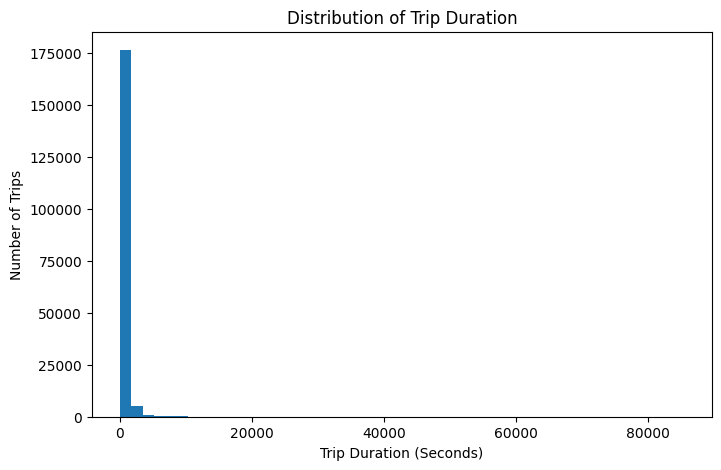

In [11]:
plt.figure(figsize=(8,5))

plt.hist(bike['duration_sec'], bins=50)

plt.title('Distribution of Trip Duration')
plt.xlabel('Trip Duration (Seconds)')
plt.ylabel('Number of Trips')

plt.show()

### Observation

The histogram shows that trip duration is highly right-skewed. Most trips last for a short duration, while a small number of trips last much longer. This indicates that bike-sharing is primarily used for short-distance travel.

### Question 2
Which user type makes the most trips?

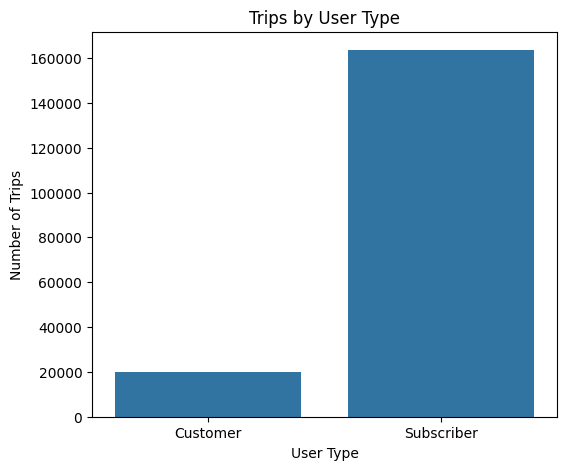

In [12]:
plt.figure(figsize=(6,5))

sns.countplot(data=bike, x='user_type')

plt.title('Trips by User Type')
plt.xlabel('User Type')
plt.ylabel('Number of Trips')

plt.show()

### Observation

Subscribers make significantly more trips than customers. This suggests that the bike-sharing system is used more frequently by regular members than by occasional users.

### Question 3
What is the distribution of member gender?

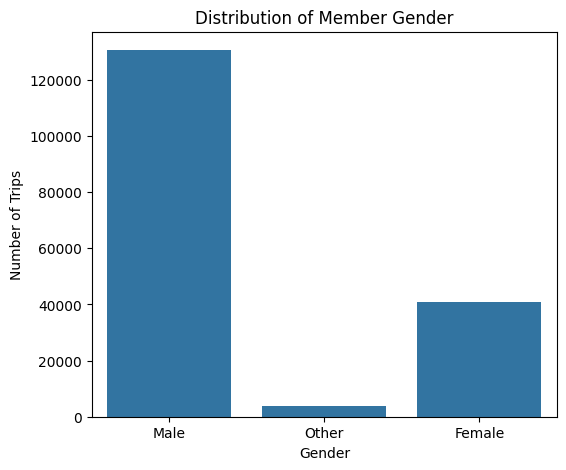

In [13]:
plt.figure(figsize=(6,5))

sns.countplot(data=bike, x='member_gender')

plt.title('Distribution of Member Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Trips')

plt.show()

### Observation

Male riders make up the largest proportion of trips, followed by female riders. A small number of riders identify as "Other."

### Discuss the distribution(s) of your variable(s) of interest. Were there any unusual points? Did you need to perform any transformations?

Trip duration is highly right-skewed, with most trips lasting only a few minutes and a small number lasting much longer. This suggests that the bike-sharing service is mainly used for short-distance travel. The long right tail indicates the presence of a few unusually long trips. To improve visualization in later analyses, a logarithmic transformation of trip duration can be useful.

### Of the features you investigated, were there any unusual distributions? Did you perform any operations on the data to tidy, adjust, or change the form of the data? If so, why did you do this?

The user type distribution shows that subscribers make significantly more trips than customers. The gender distribution indicates that male riders account for the majority of trips. No unusual distributions were observed other than the imbalance between categories. To prepare the data for analysis, the start and end time columns were converted to datetime format, and a new variable—member age—was created to support later investigations.

## Bivariate Exploration

### Question 1
Is there a relationship between rider age and trip duration?

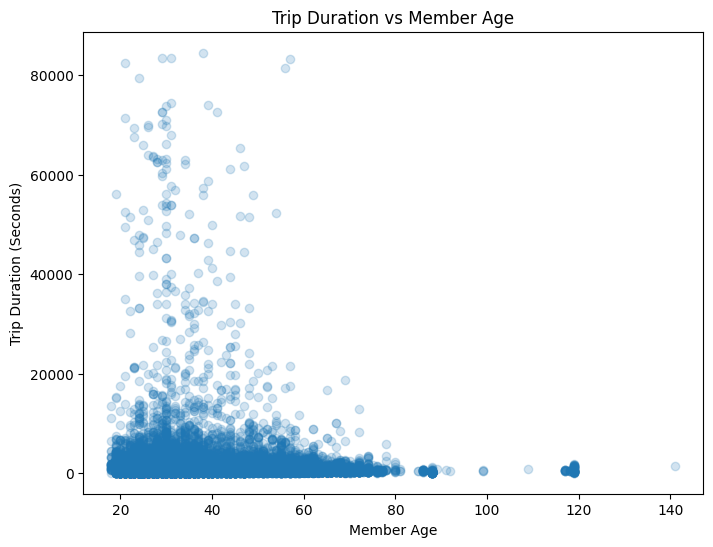

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(bike['member_age'], bike['duration_sec'], alpha=0.2)

plt.title('Trip Duration vs Member Age')
plt.xlabel('Member Age')
plt.ylabel('Trip Duration (Seconds)')

plt.show()

### Observation

Most trips are short regardless of rider age. There is no strong relationship between member age and trip duration, although a few older riders appear to have longer trips.

### Question 2
Does trip duration vary by user type?

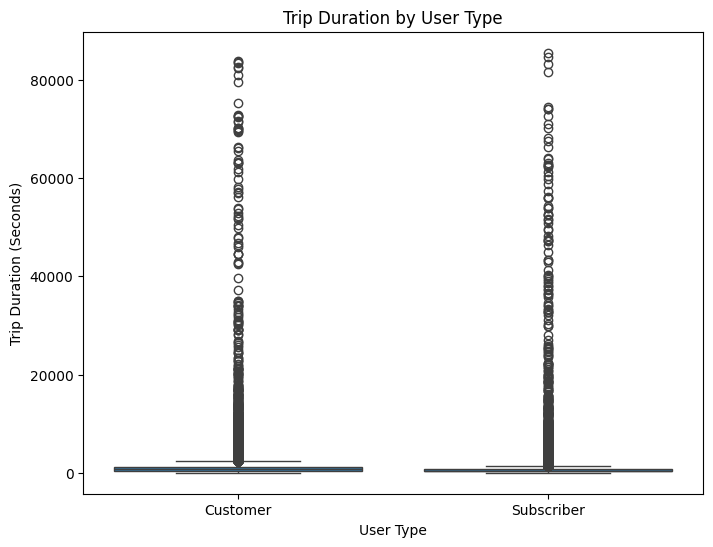

In [15]:
plt.figure(figsize=(8,6))

sns.boxplot(data=bike, x='user_type', y='duration_sec')

plt.title('Trip Duration by User Type')
plt.xlabel('User Type')
plt.ylabel('Trip Duration (Seconds)')

plt.show()

### Observation

Subscribers generally have shorter and more consistent trip durations than customers. Customers show greater variation and more long-duration trips.

### Question 3
How does user type vary across member gender?

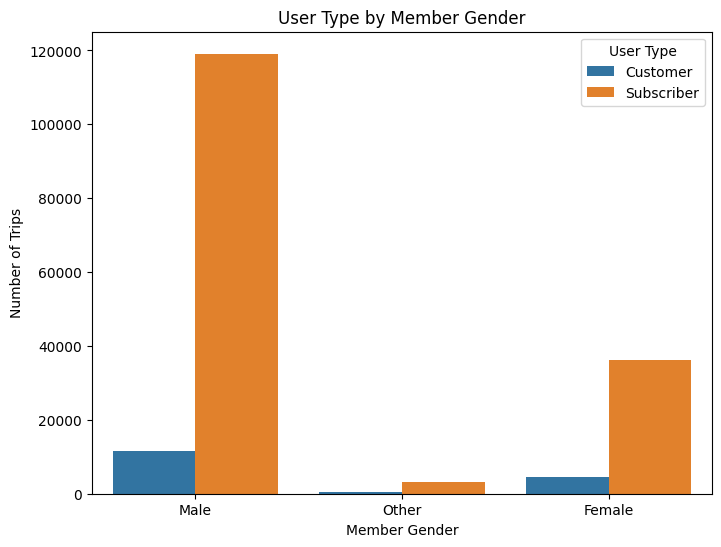

In [16]:
plt.figure(figsize=(8,6))

sns.countplot(data=bike, x='member_gender', hue='user_type')

plt.title('User Type by Member Gender')
plt.xlabel('Member Gender')
plt.ylabel('Number of Trips')
plt.legend(title='User Type')

plt.show()

### Observation

Subscribers are the dominant user type across all gender categories. Male subscribers account for the largest number of trips, followed by female subscribers.

### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

Trip duration does not show a strong relationship with rider age. However, customers generally take longer trips than subscribers, while subscribers have more consistent trip durations.

### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

The clustered bar chart shows that subscribers are the dominant user type across all genders. Male subscribers account for the largest number of trips, which is consistent with the gender distribution observed in the univariate analysis.

## Multivariate Exploration

### Question 1
How does trip duration vary with rider age across different user types?

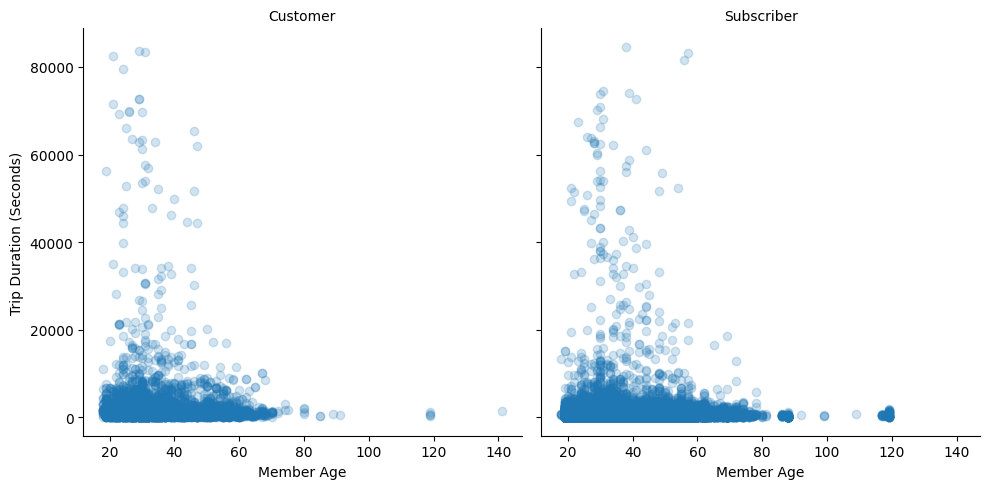

In [17]:
g = sns.FacetGrid(bike, col='user_type', height=5)

g.map(plt.scatter, 'member_age', 'duration_sec', alpha=0.2)

g.set_axis_labels('Member Age', 'Trip Duration (Seconds)')
g.set_titles('{col_name}')

plt.show()

### Observation

Both subscribers and customers generally take short trips. Customers show greater variation in trip duration, while subscribers have more consistent trip durations across different age groups.

### Question 2
How are trip duration, rider age, and user type related?

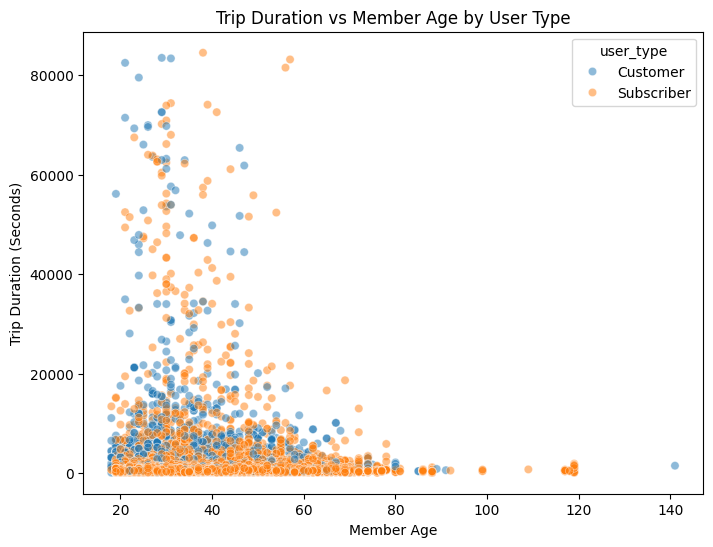

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=bike,
    x='member_age',
    y='duration_sec',
    hue='user_type',
    alpha=0.5
)

plt.title('Trip Duration vs Member Age by User Type')
plt.xlabel('Member Age')
plt.ylabel('Trip Duration (Seconds)')

plt.show()

### Observation

Trip duration does not show a strong relationship with rider age. However, customers tend to have more long-duration trips than subscribers. Most trips remain short regardless of age.

### Talk about some of the relationships you observed in this part of the investigation. Were there features that strengthened each other in terms of looking at your feature(s) of interest?

Customers generally have longer and more variable trip durations than subscribers across different age groups. Although age does not strongly influence trip duration, user type appears to have a greater effect on riding behavior.

### Were there any interesting or surprising interactions between features?

The multivariate analysis showed that user type was more strongly associated with trip duration than rider age. Subscribers consistently made shorter trips, while customers were more likely to take longer rides regardless of age.

## Conclusions

The exploratory analysis of the Ford GoBike dataset revealed several key insights:

- Most bike trips are short in duration, resulting in a highly right-skewed distribution.
- Subscribers account for the majority of bike trips and generally take shorter rides than customers.
- Male riders make up the largest proportion of users.
- Rider age has little influence on trip duration.
- User type has a stronger relationship with trip duration than rider age, with customers tending to take longer trips.

Overall, the analysis suggests that the Ford GoBike system is primarily used for short-distance commuting, especially by subscribed members.